# RefChemDB Analysis For Compound-Gene Prioritization

Paper reference [https://pmc.ncbi.nlm.nih.gov/articles/PMC6784312]

In [2]:
import polars as pl
import seaborn as sns

%matplotlib inline

## JUMP Metadata

In [3]:
# """
# Phase 1.1: Extract metadata for all perturbations using broad_babel.
# """
# from pathlib import Path
# from broad_babel.query import run_query
# from tqdm import tqdm

# # Paths
# OUTPUT_DIR = Path("../outputs/cpjump_profiles")
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# PROFILES_PATH = Path("../outputs/cpjump_profiles/profiles_wellpos_cc_var_mad_outlier_featselect_sphering_harmony.parquet")
# METADATA_PATH = Path("../outputs/metadata/perturbation_metadata.parquet")

# ## Download the profile data from S3
# # PROFILE_URL = "https://cellpainting-gallery.s3.amazonaws.com/cpg0016-jump-assembled/source_all/workspace/profiles_assembled/ALL/v1.0b/profiles_wellpos_cc_var_mad_outlier_featselect_sphering_harmony.parquet"
# # # Load the profile data (lazy load to inspect first)
# # profiles = pl.scan_parquet(PROFILE_URL)

# # # Get basic info
# # n_rows = profiles.select(pl.len()).collect().item()
# # schema = profiles.collect_schema()
# # n_cols = schema.len()
# # metadata_cols = [col for col in schema.keys() if col.startswith("Metadata")]

# # print(f"Rows: {n_rows:,}")
# # print(f"Columns: {n_cols}")
# # print(f"Metadata columns: {len(metadata_cols)}")
# # # Collect and save
# # profiles.collect().write_parquet(PROFILES_PATH)

# print("Loading profiles...")
# profiles = pl.scan_parquet(PROFILES_PATH)

# # Get unique JCP IDs
# jcp_ids = profiles.select(pl.col("Metadata_JCP2022")).unique().collect().to_series().sort().to_list()
# print(f"Total unique perturbations: {len(jcp_ids)}")

# # Use run_query for large datasets (more efficient than get_mapper)
# print("Querying broad_babel for metadata...")

# # Query for all metadata columns at once
# # run_query returns list of tuples: (JCP2022, pert_type, plate_type, standard_key)
# query = run_query(
#     tuple(jcp_ids),
#     input_column="JCP2022",
#     output_columns="JCP2022,pert_type,plate_type,standard_key"
# )

# # Convert to polars DataFrame
# metadata_df = pl.DataFrame(
#     query,
#     schema=["Metadata_JCP2022", "pert_type", "modality", "standard_key"],
#     orient="row"
# )

# print(f"Retrieved metadata for {len(metadata_df)} perturbations")
# print("\nPerturbation type distribution:")
# print(metadata_df.group_by("pert_type").len().sort("len", descending=True))
# print("\nModality distribution:")
# print(metadata_df.group_by("modality").len().sort("len", descending=True))

# # Save
# METADATA_PATH.parent.mkdir(parents=True, exist_ok=True)
# metadata_df.write_parquet(METADATA_PATH)

jump_metadata = pl.read_parquet("../outputs/metadata/perturbation_metadata.parquet")

## RefChemDB Dataset Loading and Filtering

Total unique compounds in refchemdb: 4960
Total unique targets in refchemdb: 4393


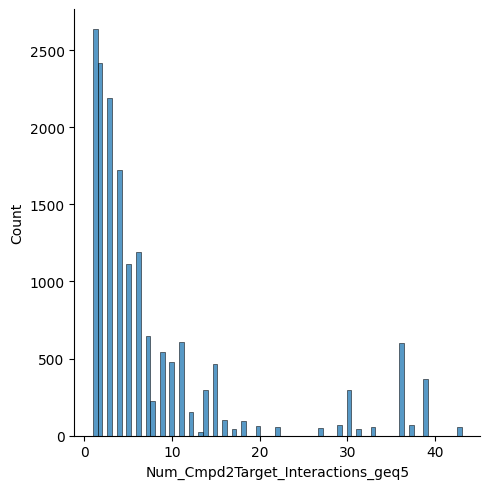

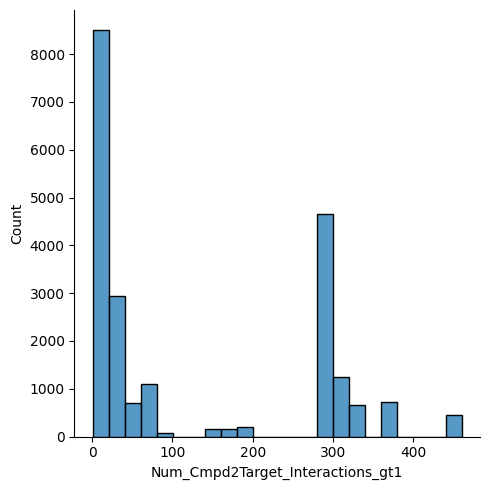

In [3]:
refchemdb_df = pl.read_csv("../outputs/refchemdb/ref_chem_overlap.csv")

## Filter only the gene targets
refchemdb_df = refchemdb_df.filter(
    pl.col("target_type") == "gene"
)

## Total number of unique compounds and target in refchemdb
print("Total unique compounds in refchemdb:", refchemdb_df.select(pl.col("Metadata_JCP2022").n_unique()).item())
print("Total unique targets in refchemdb:", refchemdb_df.select(pl.col("target").n_unique()).item())

## Filter the data frame to only include rows where support is larger than 1
refchemdb_conf_df = refchemdb_df.filter(
    pl.col("support")>1
)
refchemdb_conf_df.shape

## Gene targets per compound
refchemdb_conf_df = refchemdb_conf_df.join(
    refchemdb_conf_df.filter(
        pl.col("support")>=5,
    ).group_by(
        pl.col("Metadata_JCP2022")
    ).agg(
        pl.len()
    ).rename({"len": "Num_Cmpd2Target_Interactions_geq5"}),
    on="Metadata_JCP2022",
    how="left"
).join(
    refchemdb_conf_df.group_by(
        pl.col("Metadata_JCP2022")
    ).agg(
        pl.len()
    ).rename({"len": "Num_Cmpd2Target_Interactions_gt1"}),
    on="Metadata_JCP2022",
    how="left"
).sort(
    [pl.col("Num_Cmpd2Target_Interactions_geq5"),pl.col("Num_Cmpd2Target_Interactions_gt1")]
)

## Compounds per target gene
refchemdb_conf_df = refchemdb_conf_df.join(
    refchemdb_conf_df.filter(
        pl.col("support")>=5,
    ).group_by(
        pl.col("target")
    ).agg(
        pl.len()
    ).rename({"len": "Num_TargetByCmpd_Interactions_geq5"}),
    on="target",
    how="left"
).join(
    refchemdb_conf_df.group_by(
        pl.col("target")
    ).agg(
        pl.len()
    ).rename({"len": "Num_TargetByCmpd_Interactions_gt1"}),
    on="target",
    how="left"
).sort(
    [pl.col("Num_TargetByCmpd_Interactions_geq5"),pl.col("Num_TargetByCmpd_Interactions_gt1")]
)

sns.displot(
    data=refchemdb_conf_df.to_pandas(),
    x="Num_Cmpd2Target_Interactions_geq5",
)

sns.displot(
    data=refchemdb_conf_df.to_pandas(),
    x="Num_Cmpd2Target_Interactions_gt1",
)

In [139]:
refchemdb_conf_df = refchemdb_conf_df.with_columns(
    pl.when(
        (pl.col("Num_Cmpd2Target_Interactions_gt1") == 1) &
        (pl.col("Num_Cmpd2Target_Interactions_geq5") == 1) &
        (pl.col("Num_TargetByCmpd_Interactions_gt1") == 1) &
        (pl.col("Num_TargetByCmpd_Interactions_geq5") == 1) &
        (pl.col("mode") != "unspecified")
    )
    .then(pl.lit("Tier0"))
    .when(
        (pl.col("Num_Cmpd2Target_Interactions_geq5") == 1) &
        (pl.col("Num_Cmpd2Target_Interactions_gt1") == 1) &
        (pl.col("mode") != "unspecified")
    )
    .then(pl.lit("Tier1"))
    .when(
        (pl.col("Num_Cmpd2Target_Interactions_geq5") < 3) &
        (pl.col("mode") != "unspecified")
    )
    .then(pl.lit("Tier2"))
    .otherwise(pl.lit("Tier3"))
    .alias("CrossModalityTier")
)

# Step 1: Define eligibility criteria for each tier (cumulative—higher tiers are subsets)
refchemdb_conf_df = refchemdb_conf_df.with_columns([
    # Tier0: most stringent:
    # directional; only one mode per target; strong evidence support interaction; >1 compound
    (
        (pl.col("mode") != "unspecified") &
        (pl.col("mode").n_unique().over("target") == 1) &
        (pl.col("Num_Cmpd2Target_Interactions_geq5") == 1) &
        (pl.col("Num_Cmpd2Target_Interactions_gt1") == 1)
    ).alias("tier0_eligible"),
    
    # Tier1: relaxed
    (
        (pl.col("mode") != "unspecified") &
        (pl.col("mode").n_unique().over("target") == 1) &
        (pl.col("Num_Cmpd2Target_Interactions_geq5") == 1)
    ).alias("tier1_eligible"),
    
    # Tier2: more relaxed
    (
        (pl.col("mode") != "unspecified") &
        (pl.col("mode").n_unique().over("target") == 1)
    ).alias("tier2_eligible"),
    
    # Tier3: any duplicated target
    (pl.col("target").is_duplicated()).alias("tier3_eligible"),
])

# Step 2: Count eligible compounds per target at each tier
refchemdb_conf_df = refchemdb_conf_df.with_columns([
    pl.col("tier0_eligible").sum().over("target").alias("n_tier0"),
    pl.col("tier1_eligible").sum().over("target").alias("n_tier1"),
    pl.col("tier2_eligible").sum().over("target").alias("n_tier2"),
    pl.col("tier3_eligible").sum().over("target").alias("n_tier3"),
])

# Step 3: Assign to highest tier where BOTH eligible AND >=2 compounds exist
refchemdb_conf_df = refchemdb_conf_df.with_columns(
    pl.when((pl.col("tier0_eligible")) & (pl.col("n_tier0") >= 2))
    .then(pl.lit("Tier0"))
    .when((pl.col("tier1_eligible")) & (pl.col("n_tier1") >= 2))
    .then(pl.lit("Tier1"))
    .when((pl.col("tier2_eligible")) & (pl.col("n_tier2") >= 2))
    .then(pl.lit("Tier2"))
    .when((pl.col("tier3_eligible")) & (pl.col("n_tier3") >= 2))
    .then(pl.lit("Tier3"))
    .otherwise(pl.lit("Excluded"))
    .alias("WithinModalityTier")
)

# Optional: drop intermediate columns
refchemdb_conf_df = refchemdb_conf_df.drop([
    "tier0_eligible", "tier1_eligible", "tier2_eligible", "tier3_eligible",
    "n_tier0", "n_tier1", "n_tier2", "n_tier3"
])

In [140]:
refchemdb_conf_by_dir_df = refchemdb_conf_df.filter(
    pl.col("mode")!="unspecified"
).join(
    jump_metadata.filter(
        pl.col("modality")!="compound"
    ).rename(
        {"Metadata_JCP2022": "Metadata_JCP2022_target"}
    ).with_columns(
        pl.when(pl.col("modality")=="orf")
        .then(pl.lit("Positive"))
        .otherwise(pl.lit("Negative"))
        .alias("modality_clean")
    ),
    left_on=["target", "mode"],
    right_on=["standard_key", "modality_clean"]
).with_columns(
    pl.col("mode").alias("modality_clean"),
    pl.lit(True).alias("cmpd_pert_dir_matched"),
)

refchemdb_conf_no_dir_df = refchemdb_conf_df.filter(
    pl.col("mode")=="unspecified"
).join(
    jump_metadata.filter(
        pl.col("modality")!="compound"
    ).rename(
        {"Metadata_JCP2022": "Metadata_JCP2022_target"}
    ).with_columns(
        pl.when(pl.col("modality")=="orf")
        .then(pl.lit("Positive"))
        .otherwise(pl.lit("Negative"))
        .alias("modality_clean")
    ),
    left_on="target",
    right_on="standard_key"
).with_columns(
    pl.lit(False).alias("cmpd_pert_dir_matched")
)

refchemdb_conf_jump_df = pl.concat(
    [refchemdb_conf_by_dir_df, refchemdb_conf_no_dir_df],
    how="vertical"
)

In [56]:
## total number of unique compounds and target in refchemdb
print("Total unique compounds in refchemdb w/ support > 1:", refchemdb_conf_jump_df.select(pl.col("Metadata_JCP2022").n_unique()).item())
print("Total unique negative compounds (inhibition, etc.) in refchemdb w/ support > 1:", refchemdb_conf_jump_df.filter(pl.col("mode")=="Negative").select(pl.col("Metadata_JCP2022").n_unique()).item())
print("Total unique positive compounds (activation, etc.) in refchemdb w/ support > 1:", refchemdb_conf_jump_df.filter(pl.col("mode")=="Positive").select(pl.col("Metadata_JCP2022").n_unique()).item())
# print("Total unique unspecified compounds in refchemdb w/ support > 1:", refchemdb_conf_jump_df.filter(pl.col("mode")=="unspecified").select(pl.col("Metadata_JCP2022").n_unique()).item())

print("Total unique targets in refchemdb w/ support > 1:", refchemdb_conf_jump_df.select(pl.col("Metadata_JCP2022_target").n_unique()).item())
print("Total unique negative targets (inhibition, etc.) in refchemdb w/ support > 1:", refchemdb_conf_jump_df.filter(pl.col("modality_clean")=="Negative").select(pl.col("Metadata_JCP2022_target").n_unique()).item())
print("Total unique positive targets (activation, etc.) in refchemdb w/ support > 1:", refchemdb_conf_jump_df.filter(pl.col("modality_clean")=="Positive").select(pl.col("Metadata_JCP2022_target").n_unique()).item())
print("Total unique compound-gene pairs with matched Negative drug-perturbation in refchemdb w/ support > 1:", refchemdb_conf_jump_df.filter(
    pl.col("cmpd_pert_dir_matched")==True,
    pl.col("modality_clean")=="Negative"
).unique(subset=["Metadata_JCP2022", "Metadata_JCP2022_target"]).shape[0])

print("Total unique compound-gene pairs with matched Positive drug-perturbation in refchemdb w/ support > 1:", refchemdb_conf_jump_df.filter(
    pl.col("cmpd_pert_dir_matched")==True,
    pl.col("modality_clean")=="Positive"
).unique(subset=["Metadata_JCP2022", "Metadata_JCP2022_target"]).shape[0])

Total unique compounds in refchemdb w/ support > 1: 2064
Total unique negative compounds (inhibition, etc.) in refchemdb w/ support > 1: 1701
Total unique positive compounds (activation, etc.) in refchemdb w/ support > 1: 450
Total unique targets in refchemdb w/ support > 1: 2350
Total unique negative targets (inhibition, etc.) in refchemdb w/ support > 1: 1324
Total unique positive targets (activation, etc.) in refchemdb w/ support > 1: 1026
Total unique compound-gene pairs with matched Negative drug-perturbation in refchemdb w/ support > 1: 8208
Total unique compound-gene pairs with matched Positive drug-perturbation in refchemdb w/ support > 1: 1077


Comparison: RxRx3-core includes 736 unblinded CRISPR gene knockouts vs 1,674 compounds (each w/ 8 concentrations though). 

We have both more compounds (2064), more genes with CRISPR knockouts (1010), plus extra genes (212) with ORF overexpression comparisons.

In [ ]:
# refchemdb_conf_jump_df.write_parquet("../outputs/refchemdb/refchemdb_conf_jump_matched.parquet")

In [ ]:
refchemdb_conf_jump_df = pl.read_parquet(
    "../outputs/refchemdb/refchemdb_conf_jump_matched.parquet"
)

print(refchemdb_conf_jump_df.filter(
    pl.col("WithinModalityTier")=="Tier0"
).unique("Metadata_JCP2022").shape, 
refchemdb_conf_jump_df.filter(
    pl.col("WithinModalityTier")=="Tier0"
).unique("target")
)

(4, 23) shape: (2, 23)
┌────────┬────────────┬────────────┬────────────┬───┬───────────┬──────────┬───────────┬───────────┐
│        ┆ Metadata_J ┆ Metadata_I ┆ DTXSID     ┆ … ┆ pert_type ┆ modality ┆ modality_ ┆ cmpd_pert │
│ ---    ┆ CP2022     ┆ nChI       ┆ ---        ┆   ┆ ---       ┆ ---      ┆ clean     ┆ _dir_matc │
│ i64    ┆ ---        ┆ ---        ┆ str        ┆   ┆ str       ┆ str      ┆ ---       ┆ hed       │
│        ┆ str        ┆ str        ┆            ┆   ┆           ┆          ┆ str       ┆ ---       │
│        ┆            ┆            ┆            ┆   ┆           ┆          ┆           ┆ bool      │
╞════════╪════════════╪════════════╪════════════╪═══╪═══════════╪══════════╪═══════════╪═══════════╡
│ 103430 ┆ JCP2022_06 ┆ InChI=1S/C ┆ DTXSID7043 ┆ … ┆ trt       ┆ crispr   ┆ Negative  ┆ true      │
│        ┆ 8410       ┆ 21H17NO3/c ┆ 2975       ┆   ┆           ┆          ┆           ┆           │
│        ┆            ┆ 1-14(16-11 ┆            ┆   ┆           ┆   

## Benchmark Analysis: mAP Comparison Across Tiers (Copairs - Well Level)

Evaluate retrieval performance (mAP) using **copairs** on **well-level profiles** for:
1. **Cross-modality (compound→gene)**: Compare mAP across `CrossModalityTier` for CRISPR and ORF separately
2. **Within-modality (compound→compound)**: Compare mAP across `WithinModalityTier`

### Copairs Configuration

**Cross-modality (compound→gene retrieval):**
- `pos_sameby = ["pair_group"]` - compound and its gene target(s) grouped together
- `pos_diffby = ["modality_type"]` - only cross-modality pairs (compound↔gene) count as positives
- `neg_diffby = ["pair_group"]` - different groups are negatives

**Within-modality (compound→compound retrieval):**
- `pos_sameby = ["target_gene"]` - compounds targeting the same gene are positives
- `pos_diffby = ["Metadata_JCP2022"]` - exclude same-compound replicates
- `neg_diffby = ["target_gene"]` - different target genes are negatives

### Efficiency Parameters
- `batch_size = 20000` - process similarity calculations in batches
- `null_size = 10000` - permutations for significance testing
- `n_negative_samples = 500` - random negatives added to ensure robust comparison

In [4]:
from pathlib import Path
import numpy as np
import polars as pl
import polars.selectors as cs
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from copairs.map import average_precision, mean_average_precision

# Paths
PROFILES_PATH = Path("../outputs/cpjump_profiles/profiles_wellpos_cc_var_mad_outlier_featselect_sphering_harmony.parquet")
CURATED_DATA_PATH = Path("../outputs/refchemdb/refchemdb_conf_jump_matched.parquet")

# Load curated compound-gene pairs
curated_df = pl.read_parquet(CURATED_DATA_PATH)

# Filter for directional matched pairs only
matched_df = curated_df.filter(pl.col("cmpd_pert_dir_matched") == True)

print(f"Total curated pairs: {curated_df.height:,}")
print(f"Directionally matched pairs: {matched_df.height:,}")
print(f"\nBy modality:")
print(matched_df.group_by("modality").len().sort("modality"))
print(f"\nBy CrossModalityTier:")
print(matched_df.group_by("CrossModalityTier").len().sort("CrossModalityTier"))
print(f"\nBy WithinModalityTier:")
print(matched_df.group_by("WithinModalityTier").len().sort("WithinModalityTier"))

Total curated pairs: 34,004
Directionally matched pairs: 9,499

By modality:
shape: (2, 2)
┌──────────┬──────┐
│ modality ┆ len  │
│ ---      ┆ ---  │
│ str      ┆ u32  │
╞══════════╪══════╡
│ crispr   ┆ 8362 │
│ orf      ┆ 1137 │
└──────────┴──────┘

By CrossModalityTier:
shape: (4, 2)
┌───────────────────┬──────┐
│ CrossModalityTier ┆ len  │
│ ---               ┆ ---  │
│ str               ┆ u32  │
╞═══════════════════╪══════╡
│ Tier0             ┆ 7    │
│ Tier1             ┆ 49   │
│ Tier2             ┆ 2488 │
│ Tier3             ┆ 6955 │
└───────────────────┴──────┘

By WithinModalityTier:
shape: (5, 2)
┌────────────────────┬──────┐
│ WithinModalityTier ┆ len  │
│ ---                ┆ ---  │
│ str                ┆ u32  │
╞════════════════════╪══════╡
│ Excluded           ┆ 196  │
│ Tier0              ┆ 4    │
│ Tier1              ┆ 186  │
│ Tier2              ┆ 1599 │
│ Tier3              ┆ 7514 │
└────────────────────┴──────┘


In [5]:
# Load profiles (lazy for efficiency)
profiles_lf = pl.scan_parquet(PROFILES_PATH)

# Get profile schema to identify feature columns
schema = profiles_lf.collect_schema()
feature_cols = [c for c in schema.names() if not c.startswith("Metadata")]
metadata_cols = [c for c in schema.names() if c.startswith("Metadata")]

print(f"Total features: {len(feature_cols)}")
print(f"Metadata columns: {metadata_cols}")

# Get replicate counts per perturbation
replicate_counts = profiles_lf.group_by("Metadata_JCP2022").agg(
    pl.len().alias("n_replicates")
).collect()

# Filter perturbations with >= 4 replicates (for reliable mAP calculation)
perts_with_4_reps = replicate_counts.filter(pl.col("n_replicates") >= 4)["Metadata_JCP2022"].to_list()
print(f"\nPerturbations with >= 4 replicates: {len(perts_with_4_reps):,}")

Total features: 614
Metadata columns: ['Metadata_Source', 'Metadata_Plate', 'Metadata_Well', 'Metadata_JCP2022']



Perturbations with >= 4 replicates: 118,860


In [6]:
from pathlib import Path
import numpy as np
import polars as pl
import polars.selectors as cs
import pandas as pd
from copairs.map import average_precision, mean_average_precision

# =============================================================================
# COPAIRS-BASED HELPER FUNCTIONS (WELL-LEVEL PROFILES)
# =============================================================================

def prepare_cross_modality_data(
    pairs_df: pl.DataFrame,
    profiles_lf: pl.LazyFrame,
    n_negative_samples: int = 50,
    min_replicates: int = 4,
    seed: int = 42,
) -> tuple[pd.DataFrame, np.ndarray]:
    """
    Prepare well-level data for cross-modality mAP calculation using copairs.
    
    Creates a unified dataset where:
    - Each compound and its target gene(s) share the same "pair_group" 
    - Different modalities (compound vs gene) are marked for pos_diffby
    - Random negatives are added to ensure robust comparison
    
    Returns:
        meta_df: pandas DataFrame with metadata columns
        features: numpy array of feature values
    """
    np.random.seed(seed)
    
    # Get unique compound and target IDs
    compound_ids = pairs_df["Metadata_JCP2022"].unique().to_list()
    target_ids = pairs_df["Metadata_JCP2022_target"].unique().to_list()
    positive_ids = list(set(compound_ids + target_ids))
    
    # Sample random negatives from perturbations not in our pairs
    all_perts = profiles_lf.select("Metadata_JCP2022").unique().collect()["Metadata_JCP2022"].to_list()
    available_negatives = [p for p in all_perts if p not in positive_ids]
    n_sample = min(n_negative_samples, len(available_negatives))
    negative_ids = list(np.random.choice(available_negatives, n_sample, replace=False))
    
    all_ids = positive_ids + negative_ids
    
    # Load well-level profiles (NOT aggregated)
    profiles_df = profiles_lf.filter(
        pl.col("Metadata_JCP2022").is_in(all_ids)
    ).collect()
    
    if profiles_df.height == 0:
        return None, None
    
    # Build compound→target_group mapping
    # Each compound-target pair gets a unique group ID
    compound_to_groups = {}
    target_to_groups = {}
    group_id = 0
    
    for row in pairs_df.iter_rows(named=True):
        cmpd = row["Metadata_JCP2022"]
        tgt = row["Metadata_JCP2022_target"]
        
        # Create a group for this compound-target pair
        group_name = f"group_{group_id}"
        group_id += 1
        
        if cmpd not in compound_to_groups:
            compound_to_groups[cmpd] = []
        compound_to_groups[cmpd].append(group_name)
        
        if tgt not in target_to_groups:
            target_to_groups[tgt] = []
        target_to_groups[tgt].append(group_name)
    
    # Assign pair_group to each well
    # For compounds/targets with multiple groups, we use the first one (simplified)
    def get_pair_group(jcp_id):
        if jcp_id in compound_to_groups:
            return compound_to_groups[jcp_id][0]
        elif jcp_id in target_to_groups:
            return target_to_groups[jcp_id][0]
        else:
            return f"neg_{jcp_id}"  # Negatives get unique groups
    
    def get_modality_type(jcp_id):
        if jcp_id in compound_ids:
            return "compound"
        elif jcp_id in target_ids:
            return "gene"
        else:
            return "negative"
    
    # Add metadata columns for copairs
    profiles_df = profiles_df.with_columns([
        pl.col("Metadata_JCP2022").map_elements(get_pair_group, return_dtype=pl.Utf8).alias("pair_group"),
        pl.col("Metadata_JCP2022").map_elements(get_modality_type, return_dtype=pl.Utf8).alias("modality_type"),
    ])
    
    # Separate metadata and features
    metadata_cols = ["Metadata_Source", "Metadata_Plate", "Metadata_Well", "Metadata_JCP2022", 
                     "pair_group", "modality_type"]
    feature_cols = [c for c in profiles_df.columns if c not in metadata_cols]
    
    meta_df = profiles_df.select(metadata_cols).to_pandas()
    features = profiles_df.select(feature_cols).to_numpy()
    
    return meta_df, features


def prepare_within_modality_data(
    pairs_df: pl.DataFrame,
    profiles_lf: pl.LazyFrame,
    n_negative_samples: int = 50,
    min_replicates: int = 4,
    seed: int = 42,
) -> tuple[pd.DataFrame, np.ndarray]:
    """
    Prepare well-level data for within-modality (compound→compound) mAP using copairs.
    
    Creates a dataset where:
    - Compounds targeting the same gene share the same "target" value
    - Random negatives are added with unique target values
    
    Returns:
        meta_df: pandas DataFrame with metadata columns
        features: numpy array of feature values
    """
    np.random.seed(seed)
    
    # Get unique compound IDs and their target genes
    compound_ids = pairs_df["Metadata_JCP2022"].unique().to_list()
    
    # Build compound→target mapping
    compound_to_target = {}
    for row in pairs_df.iter_rows(named=True):
        compound_to_target[row["Metadata_JCP2022"]] = row["target"]
    
    # Sample random negatives
    all_perts = profiles_lf.select("Metadata_JCP2022").unique().collect()["Metadata_JCP2022"].to_list()
    available_negatives = [p for p in all_perts if p not in compound_ids]
    n_sample = min(n_negative_samples, len(available_negatives))
    negative_ids = list(np.random.choice(available_negatives, n_sample, replace=False))
    
    all_ids = compound_ids + negative_ids
    
    # Load well-level profiles
    profiles_df = profiles_lf.filter(
        pl.col("Metadata_JCP2022").is_in(all_ids)
    ).collect()
    
    if profiles_df.height == 0:
        return None, None
    
    # Assign target gene to each well (negatives get unique "targets")
    def get_target(jcp_id):
        if jcp_id in compound_to_target:
            return compound_to_target[jcp_id]
        else:
            return f"neg_{jcp_id}"  # Each negative is its own "target"
    
    profiles_df = profiles_df.with_columns([
        pl.col("Metadata_JCP2022").map_elements(get_target, return_dtype=pl.Utf8).alias("target_gene"),
    ])
    
    # Separate metadata and features
    metadata_cols = ["Metadata_Source", "Metadata_Plate", "Metadata_Well", "Metadata_JCP2022", "target_gene"]
    feature_cols = [c for c in profiles_df.columns if c not in metadata_cols]
    
    meta_df = profiles_df.select(metadata_cols).to_pandas()
    features = profiles_df.select(feature_cols).to_numpy()
    
    return meta_df, features


def compute_cross_modality_map_copairs(
    pairs_df: pl.DataFrame,
    profiles_lf: pl.LazyFrame,
    n_negative_samples: int = 50,
    batch_size: int = 20000,
    null_size: int = 1000,
    seed: int = 42,
) -> dict:
    """
    Compute cross-modality mAP using copairs on well-level profiles.
    
    Copairs parameters:
    - pos_sameby: ["pair_group"] - compound and its gene target(s) in same group
    - pos_diffby: ["modality_type"] - only cross-modality pairs count as positives
    - neg_diffby: ["pair_group"] - different groups are negatives
    """
    meta_df, features = prepare_cross_modality_data(
        pairs_df, profiles_lf, n_negative_samples, seed=seed
    )
    
    if meta_df is None:
        return {"mAP": None, "error": "No profiles found"}
    
    # Copairs parameters for cross-modality
    pos_sameby = ["pair_group"]      # Match compound-gene pairs in same group
    pos_diffby = ["modality_type"]   # Only count cross-modality pairs (compound↔gene)
    neg_sameby = []
    neg_diffby = ["pair_group"]      # Different groups are negatives
    
    try:
        # Step 1: Calculate well-level average precision
        ap_result = average_precision(
            meta_df,
            features,
            pos_sameby,
            pos_diffby,
            neg_sameby,
            neg_diffby,
            batch_size,
        )
        
        ap_df = pd.DataFrame(ap_result)
        
        # Filter to only compound wells (we want compound→gene retrieval)
        compound_ap = ap_df[ap_df["modality_type"] == "compound"]
        
        if len(compound_ap) == 0:
            return {"mAP": None, "error": "No compound wells found"}
        
        # Step 2: Calculate mAP with significance testing
        mAP_result = mean_average_precision(
            ap_df,
            sameby=pos_sameby,
            null_size=null_size,
            threshold=0.05,
            seed=seed,
        )
        
        mAP_df = pd.DataFrame(mAP_result)
        
        return {
            "mAP": compound_ap["average_precision"].mean(),
            "median_AP": compound_ap["average_precision"].median(),
            "std_AP": compound_ap["average_precision"].std(),
            "n_wells": len(compound_ap),
            "n_compounds": compound_ap["Metadata_JCP2022"].nunique(),
            "n_negative_samples": n_negative_samples,
            "ap_df": ap_df,
            "mAP_df": mAP_df,
        }
        
    except Exception as e:
        return {"mAP": None, "error": str(e)}


def compute_within_modality_map_copairs(
    pairs_df: pl.DataFrame,
    profiles_lf: pl.LazyFrame,
    n_negative_samples: int = 500,
    batch_size: int = 20000,
    null_size: int = 10000,
    seed: int = 42,
) -> dict:
    """
    Compute within-modality (compound→compound) mAP using copairs on well-level profiles.
    
    Copairs parameters:
    - pos_sameby: ["target_gene"] - compounds targeting same gene are positives
    - pos_diffby: ["Metadata_JCP2022"] - exclude same-compound replicates
    - neg_diffby: ["target_gene"] - different target genes are negatives
    """
    meta_df, features = prepare_within_modality_data(
        pairs_df, profiles_lf, n_negative_samples, seed=seed
    )
    
    if meta_df is None:
        return {"mAP": None, "error": "No profiles found"}
    
    # Copairs parameters for within-modality
    pos_sameby = ["target_gene"]         # Compounds with same target gene
    pos_diffby = ["Metadata_JCP2022"]    # Exclude same-compound pairs (only inter-compound)
    neg_sameby = []
    neg_diffby = ["target_gene"]         # Different target genes are negatives
    
    try:
        # Step 1: Calculate well-level average precision
        ap_result = average_precision(
            meta_df,
            features,
            pos_sameby,
            pos_diffby,
            neg_sameby,
            neg_diffby,
            batch_size,
        )
        
        ap_df = pd.DataFrame(ap_result)
        
        # Filter to only compound wells (exclude negatives)
        compound_ids = pairs_df["Metadata_JCP2022"].unique().to_list()
        compound_ap = ap_df[ap_df["Metadata_JCP2022"].isin(compound_ids)]
        
        if len(compound_ap) == 0:
            return {"mAP": None, "error": "No compound wells found"}
        
        # Step 2: Calculate mAP with significance testing
        mAP_result = mean_average_precision(
            ap_df,
            sameby=pos_sameby,
            null_size=null_size,
            threshold=0.05,
            seed=seed,
        )
        
        mAP_df = pd.DataFrame(mAP_result)
        
        return {
            "mAP": compound_ap["average_precision"].mean(),
            "median_AP": compound_ap["average_precision"].median(),
            "std_AP": compound_ap["average_precision"].std(),
            "n_wells": len(compound_ap),
            "n_compounds": compound_ap["Metadata_JCP2022"].nunique(),
            "n_negative_samples": n_negative_samples,
            "ap_df": ap_df,
            "mAP_df": mAP_df,
        }
        
    except Exception as e:
        return {"mAP": None, "error": str(e)}


print("Copairs-based helper functions defined (uses WELL-LEVEL profiles)")
print("  - compute_cross_modality_map_copairs: compound→gene retrieval")
print("  - compute_within_modality_map_copairs: compound→compound retrieval")

Copairs-based helper functions defined (uses WELL-LEVEL profiles)
  - compute_cross_modality_map_copairs: compound→gene retrieval
  - compute_within_modality_map_copairs: compound→compound retrieval


In [7]:
%%time
### Task 1: Cross-Modality Compound→Gene Retrieval by Tier (COPAIRS - WELL LEVEL)

cross_modality_results = []
cross_modality_ap_dfs = {}  # Store detailed AP results
tiers = ["Tier0", "Tier1", "Tier2", "Tier3"]
modalities = ["crispr", "orf"]

# Parameters
N_NEGATIVE_SAMPLES = 20  # Number of random negative perturbations to include
BATCH_SIZE = 20000        # Copairs batch size for efficiency
NULL_SIZE = 1000         # Permutations for significance testing
SEED = 42

print("=" * 70)
print("TASK 1: Cross-Modality Compound→Gene Retrieval (COPAIRS - WELL LEVEL)")
print("=" * 70)
print(f"Parameters: n_negatives={N_NEGATIVE_SAMPLES}, batch_size={BATCH_SIZE}, null_size={NULL_SIZE}")

for modality in modalities:
    print(f"\n### {modality.upper()} ###")
    for tier in tiers:
        tier_pairs = matched_df.filter(
            (pl.col("CrossModalityTier") == tier) &
            (pl.col("modality") == modality)
        ).unique(subset=["Metadata_JCP2022", "Metadata_JCP2022_target"])
        
        if tier_pairs.shape[0] > 100:
            tier_pairs = tier_pairs.sample(100, seed=SEED)  # Sample for faster testing (remove in real runs)

        n_pairs = tier_pairs.height
        n_compounds = tier_pairs["Metadata_JCP2022"].n_unique()
        n_targets = tier_pairs["Metadata_JCP2022_target"].n_unique()
        
        if n_pairs < 2:
            print(f"  {tier}: Skipped (only {n_pairs} pairs)")
            cross_modality_results.append({
                "modality": modality, "tier": tier, "n_pairs": n_pairs,
                "n_compounds": n_compounds, "n_targets": n_targets,
                "mAP": None, "median_AP": None, "std_AP": None, "n_wells": None,
            })
            continue
        
        result = compute_cross_modality_map_copairs(
            tier_pairs, 
            profiles_lf, 
            n_negative_samples=N_NEGATIVE_SAMPLES,
            batch_size=BATCH_SIZE,
            null_size=NULL_SIZE,
            seed=SEED,
        )
        
        # Store AP dataframe for detailed analysis
        if "ap_df" in result:
            cross_modality_ap_dfs[f"{modality}_{tier}"] = result.pop("ap_df")
        if "mAP_df" in result:
            result.pop("mAP_df")  # Remove from results dict but could be saved
        
        cross_modality_results.append({
            "modality": modality, "tier": tier, "n_pairs": n_pairs,
            "n_compounds": n_compounds, "n_targets": n_targets, **result
        })
        
        if result.get("mAP") is not None:
            print(f"  {tier}: mAP={result['mAP']:.4f} ± {result.get('std_AP', 0):.4f} "
                  f"(n={n_compounds} compounds, {n_targets} targets, {result.get('n_wells', 0)} wells)")
        else:
            print(f"  {tier}: {result.get('error', 'Error')}")

cross_modality_df = pd.DataFrame(cross_modality_results)
print("\n" + "=" * 70)

TASK 1: Cross-Modality Compound→Gene Retrieval (COPAIRS - WELL LEVEL)
Parameters: n_negatives=20, batch_size=20000, null_size=1000

### CRISPR ###


/home/shenrunx/.cache/pypoetry/virtualenvs/jump-compound-annotator-hy9C9YqJ-py3.10/lib/python3.10/site-packages/copairs/compute.py:50: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

  0%|          | 0/53 [00:00<?, ?it/s]

  Tier3: mAP=0.0071 ± 0.0124 (n=76 compounds, 69 targets, 1626 wells)

CPU times: user 7min 5s, sys: 8min 21s, total: 15min 26s
Wall time: 2min 38s


In [ ]:
%%time
### Task 2: Within-Modality Compound→Compound Retrieval by Tier (COPAIRS - WELL LEVEL)

within_modality_results = []
within_modality_ap_dfs = {}  # Store detailed AP results

print("=" * 70)
print("TASK 2: Within-Modality Compound→Compound Retrieval (COPAIRS - WELL LEVEL)")
print("=" * 70)
print(f"Parameters: n_negatives={N_NEGATIVE_SAMPLES}, batch_size={BATCH_SIZE}, null_size={NULL_SIZE}")

for tier in ["Tier0", "Tier1", "Tier2", "Tier3"]:
    tier_pairs = matched_df.filter(
        pl.col("WithinModalityTier") == tier
    ).unique(subset=["Metadata_JCP2022", "target"])
    
    if tier_pairs.shape[0] > 100:
        tier_pairs = tier_pairs.sample(100, seed=SEED)  # Sample for faster testing (remove in real runs)

    n_pairs = tier_pairs.height
    n_compounds = tier_pairs["Metadata_JCP2022"].n_unique()
    n_targets = tier_pairs["target"].n_unique()
    
    if n_compounds < 2:
        print(f"{tier}: Skipped (only {n_compounds} compounds)")
        within_modality_results.append({
            "tier": tier, "n_pairs": n_pairs, "n_compounds": n_compounds,
            "n_targets": n_targets, "mAP": None, "median_AP": None, "std_AP": None, "n_wells": None,
        })
        continue
    
    result = compute_within_modality_map_copairs(
        tier_pairs, 
        profiles_lf, 
        n_negative_samples=N_NEGATIVE_SAMPLES,
        batch_size=BATCH_SIZE,
        null_size=NULL_SIZE,
        seed=SEED,
    )
    
    # Store AP dataframe for detailed analysis
    if "ap_df" in result:
        within_modality_ap_dfs[tier] = result.pop("ap_df")
    if "mAP_df" in result:
        result.pop("mAP_df")
    
    within_modality_results.append({
        "tier": tier, "n_pairs": n_pairs, "n_compounds": n_compounds,
        "n_targets": n_targets, **result
    })
    
    if result.get("mAP") is not None:
        print(f"{tier}: mAP={result['mAP']:.4f} ± {result.get('std_AP', 0):.4f} "
              f"(n={n_compounds} compounds, {result.get('n_wells', 0)} wells)")
    else:
        print(f"{tier}: {result.get('error', 'Error')}")

within_modality_df = pd.DataFrame(within_modality_results)
print("\n" + "=" * 70)

TASK 2: Within-Modality Compound→Compound Retrieval (COPAIRS - WELL LEVEL)
Parameters: n_negatives=20, batch_size=20000, null_size=1000


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

...

  0%|          | 0/16 [00:00<?, ?it/s]

Tier1: mAP=0.0795 ± 0.1001 (n=66 compounds, 1493 wells)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  0%|          | 0/1102 [00:00<?, ?it/s]

  0%|          | 0/18340 [00:00<?, ?it/s]

In [ ]:
## Visualization: mAP Comparison Across Tiers (with error bars)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cross-Modality by Tier and Modality
ax1 = axes[0]
cross_plot_df = cross_modality_df[cross_modality_df["mAP"].notna()].copy()

if len(cross_plot_df) > 0:
    bar_width = 0.35
    tiers_order = ["Tier0", "Tier1", "Tier2", "Tier3"]
    tiers_with_data = [t for t in tiers_order if t in cross_plot_df["tier"].values]
    x = np.arange(len(tiers_with_data))
    
    for i, modality in enumerate(["crispr", "orf"]):
        mod_data = cross_plot_df[cross_plot_df["modality"] == modality]
        if len(mod_data) > 0:
            mAP_values = []
            std_values = []
            for tier in tiers_with_data:
                tier_data = mod_data[mod_data["tier"] == tier]
                if len(tier_data) > 0:
                    mAP_values.append(tier_data["mAP"].values[0])
                    std_val = tier_data["std_AP"].values[0] if "std_AP" in tier_data.columns else 0
                    std_values.append(std_val if pd.notna(std_val) else 0)
                else:
                    mAP_values.append(0)
                    std_values.append(0)
            
            ax1.bar(x + i * bar_width, mAP_values, bar_width, 
                   yerr=std_values, capsize=3,
                   label=modality.upper(), alpha=0.8)
    
    ax1.set_xlabel("CrossModalityTier")
    ax1.set_ylabel("mAP (well-level)")
    ax1.set_title("Cross-Modality: Compound→Gene Retrieval\n(copairs, well-level)")
    ax1.set_xticks(x + bar_width / 2)
    ax1.set_xticklabels(tiers_with_data)
    ax1.legend()
    ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
else:
    ax1.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax1.transAxes)

# Plot 2: Within-Modality by Tier
ax2 = axes[1]
within_plot_df = within_modality_df[within_modality_df["mAP"].notna()].copy()

if len(within_plot_df) > 0:
    tiers_order = ["Tier0", "Tier1", "Tier2", "Tier3"]
    within_plot_df = within_plot_df.set_index("tier").reindex(tiers_order).dropna(subset=["mAP"]).reset_index()
    
    tiers = within_plot_df["tier"].tolist()
    mAP_values = within_plot_df["mAP"].tolist()
    std_values = within_plot_df["std_AP"].fillna(0).tolist() if "std_AP" in within_plot_df.columns else [0] * len(tiers)
    n_compounds = within_plot_df["n_compounds"].tolist()
    
    bars = ax2.bar(tiers, mAP_values, yerr=std_values, capsize=3, alpha=0.8, color='steelblue')
    
    # Add compound counts on bars
    for bar, n in zip(bars, n_compounds):
        height = bar.get_height()
        ax2.annotate(f'n={n}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 8),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)
    
    ax2.set_xlabel("WithinModalityTier")
    ax2.set_ylabel("mAP (well-level)")
    ax2.set_title("Within-Modality: Compound→Compound Retrieval\n(copairs, well-level)")
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
else:
    ax2.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax2.transAxes)

plt.tight_layout()
plt.savefig("../outputs/refchemdb/tier_mAP_comparison_copairs_welllevel.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to: outputs/refchemdb/tier_mAP_comparison_copairs_welllevel.png")

In [ ]:
## Summary Statistics

print("=" * 70)
print("BENCHMARK SUMMARY: RefChemDB Tier Comparison (COPAIRS - WELL LEVEL)")
print("=" * 70)

print("\n### Task 1: Cross-Modality (Compound→Gene) ###")
print("\nCRISPR:")
crispr_df = cross_modality_df[cross_modality_df["modality"] == "crispr"]
for _, row in crispr_df.iterrows():
    if pd.notna(row["mAP"]):
        std_str = f"±{row['std_AP']:.4f}" if pd.notna(row.get('std_AP')) else ""
        wells_str = f", {int(row['n_wells'])} wells" if pd.notna(row.get('n_wells')) else ""
        print(f"  {row['tier']}: mAP={row['mAP']:.4f} {std_str} | n_compounds={row['n_compounds']}, n_targets={row['n_targets']}{wells_str}")
    else:
        print(f"  {row['tier']}: N/A (n_pairs={row['n_pairs']})")

print("\nORF:")
orf_df = cross_modality_df[cross_modality_df["modality"] == "orf"]
for _, row in orf_df.iterrows():
    if pd.notna(row["mAP"]):
        std_str = f"±{row['std_AP']:.4f}" if pd.notna(row.get('std_AP')) else ""
        wells_str = f", {int(row['n_wells'])} wells" if pd.notna(row.get('n_wells')) else ""
        print(f"  {row['tier']}: mAP={row['mAP']:.4f} {std_str} | n_compounds={row['n_compounds']}, n_targets={row['n_targets']}{wells_str}")
    else:
        print(f"  {row['tier']}: N/A (n_pairs={row['n_pairs']})")

print("\n### Task 2: Within-Modality (Compound→Compound) ###")
for _, row in within_modality_df.iterrows():
    if pd.notna(row["mAP"]):
        std_str = f"±{row['std_AP']:.4f}" if pd.notna(row.get('std_AP')) else ""
        wells_str = f", {int(row['n_wells'])} wells" if pd.notna(row.get('n_wells')) else ""
        print(f"  {row['tier']}: mAP={row['mAP']:.4f} {std_str} | n_compounds={row['n_compounds']}, n_targets={row['n_targets']}{wells_str}")
    else:
        print(f"  {row['tier']}: N/A (n_compounds={row['n_compounds']})")

print("\n" + "=" * 70)
print("KEY OBSERVATIONS:")
print("=" * 70)

# Calculate tier differences
cross_valid = cross_modality_df[cross_modality_df["mAP"].notna()]
within_valid = within_modality_df[within_modality_df["mAP"].notna()]

if len(cross_valid) > 1:
    best_cross = cross_valid.loc[cross_valid["mAP"].idxmax()]
    print(f"- Best cross-modality: {best_cross['tier']} ({best_cross['modality']}) with mAP={best_cross['mAP']:.4f}")

if len(within_valid) > 1:
    best_within = within_valid.loc[within_valid["mAP"].idxmax()]
    print(f"- Best within-modality: {best_within['tier']} with mAP={best_within['mAP']:.4f}")
    
print("\nExpectation: Higher tiers (Tier0 > Tier1 > Tier2 > Tier3) should have better mAP")
print("as they represent more confident compound-gene relationships.")
print("\nNote: Using WELL-LEVEL profiles with copairs (not aggregated perturbation-level).")

In [ ]:
# # Save results to CSV
# cross_modality_df.to_csv("../outputs/refchemdb/benchmark_cross_modality_results_copairs_welllevel.csv", index=False)
# within_modality_df.to_csv("../outputs/refchemdb/benchmark_within_modality_results_copairs_welllevel.csv", index=False)

# # Optionally save detailed AP results per well
# import os
# os.makedirs("../outputs/refchemdb/ap_details", exist_ok=True)

# for key, ap_df in cross_modality_ap_dfs.items():
#     ap_df.to_csv(f"../outputs/refchemdb/ap_details/cross_modality_{key}_ap.csv", index=False)

# for key, ap_df in within_modality_ap_dfs.items():
#     ap_df.to_csv(f"../outputs/refchemdb/ap_details/within_modality_{key}_ap.csv", index=False)

# print("Results saved:")
# print("  - outputs/refchemdb/benchmark_cross_modality_results_copairs_welllevel.csv")
# print("  - outputs/refchemdb/benchmark_within_modality_results_copairs_welllevel.csv")
# print("  - outputs/refchemdb/tier_mAP_comparison_copairs_welllevel.png")
# print(f"  - outputs/refchemdb/ap_details/ ({len(cross_modality_ap_dfs) + len(within_modality_ap_dfs)} AP detail files)")